# Generador de Datasets PINN para Diseño de Motores PMSM

Este notebook genera un dataset de diseños de motores PMSM utilizando
Muestreo usando Latin Hypercube Sampling (LHS) para el
entrenamiento de Redes Neuronales Informadas por la Física (PINN), también conocidas como Redes Neuronales Asistidas por la Física (PANN).

**Estructura de salida:**
```
dataset/
    designs.csv          # Todos los parámetros de diseño y resultados
    designs/
        model0001.fem    # Archivos de modelo FEMM
        model0002.fem
        ...
```

El Notebook se divide en 2:
- La primera parte genera las muestras usando LHS y las siguientes variables:
bounds = {
    'b': b_bounds,
    'l': (0.35, 0.70),
    'outer_radius': (0.04, 0.10),
}
Siendo 'b' y 'l' los parámetros para el diseño del paramétrico del motor (ver referencia)
Las muestras son construidas en la herramienta de Análisis por Elementos Finitos para electromagnetismo FEMM y guardadas segun la estructura de directorios que se muestra arriba
También se realizan el análisis de cada motor construido con el Modelo Analítico (ver referencia). Este modelo se utilizará en el notebook de aprendizaje para "informar" o "asistir" a la NN 

- La segunda parte realiza la evaluación de torque con los siguientes pasos
    - Rota la señal trifásica de exitación hasta encontrar el ángulo para máximo torque
    - Realiza un barrido de 360 grados eléctricos, calculando el torque cada 5 grados, para obtener la forma de onda completa del torque del motor, incluido el ripple. Los resultados son guardados en los archivos: WAVEFORM_DIRS/RESULTS_PATH


- Para ejecutar el notebook se necesitan las siguientes dependencias:
    - La clase `PMSM` y los helpers de LHS se importan desde `arfemm/lib/python/pmsm.py`.
    - `FEMM` se instala desde www.femm4.info
    - `KOIL` se necesita para el esquema del bobinado

In [1]:
import sys
import os
import csv
import time
from typing import Dict, Any

import numpy as np

# Path to the pmsm module inside arfemm
sys.path.insert(0, r"c:\Proyectos\arfemm\lib\python")

from pmsm import (
    PMSM,
    latin_hypercube_sampling,
    latin_hypercube_sampling_scipy,
    FEMM_AVAILABLE,
)

try:
    import femm
except ImportError:
    pass

print(f"FEMM available: {FEMM_AVAILABLE}")

FEMM available: True


## Configuración

- Límites de parámetros Default para el muestreo LHS 
- Parámetros no variables para la construcción del motor
- Orden de las columnas del CSV de salida

In [2]:
def calculate_b_bounds(magnet_br: float = 1.45, kl: float = 0.98,
                       bh: float = 1.5, pc_min: float = 1.5,
                       pc_max: float = 5.0) -> tuple:
    """
    Calculate valid bounds for flux density ratio 'b' based on
    permeance coefficient constraints.

    PC = magnet_thickness / airgap_thickness must lie in [pc_min, pc_max].
    """
    bmin = magnet_br * kl / (bh * (1/pc_min + 1))
    bmax = magnet_br * kl / (bh * (1/pc_max + 1))
    return (bmin, bmax)


DEFAULT_BOUNDS = {
    'b': calculate_b_bounds(),        # Bg/Bh ratio from PC constraints
    'x': (0.35, 0.70),               # Radius ratio (Ro-Ri)/Ro
    'stator_length': (0.015, 0.040), # Axial length [m]
    'outer_radius': (0.04, 0.10),    # Motor outer radius [m]
    'airgap_thickness': (0.0005, 0.0015),  # Airgap [m]
    'current_density': (5e6, 15e6),  # Current density [A/m^2]
    'turns': (1, 5),                 # Turns per coil (rounded)
    'rotation_speed': (1000, 5000),  # RPM
}

DEFAULT_FIXED_PARAMS = {
    'slots': 18,
    'pp': 12,
    'fill_factor': 0.4,
    'magnet_br': 1.45,
    'magnet_ur': 1.05,
    'magnet_type': 'N52',
    'hh_thickness': 0.002,
    'hh_radius': 0.002,
    'k1': 1,
    'k2': 0.02,
}

OUTPUT_COLUMNS = [
    'sample_id',
    'b', 'x',
    'stator_length', 'outer_radius', 'airgap_thickness',
    'current_density', 'turns', 'rotation_speed',
    'slots', 'pp',
    'magnet_thickness', 'magnet_width', 'backiron_thickness',
    'airgap_radius', 'stator_outer_radius', 'slot_length',
    'tooth_width', 'wire_diameter', 'coil_area',
    'torque', 'total_mass', 'specific_torque', 'efficiency',
    'kt', 'km', 'phase_current', 'phase_resistance',
    'phase_voltage', 'winding_losses', 'core_losses',
    'mechanical_power', 'total_losses',
    'error_code', 'fem_file'
]

## Funciones Auxiliares

In [5]:
def create_motor_from_params(params: Dict[str, float],
                             fixed_params: Dict[str, Any] = None) -> PMSM:
    """Create a PMSM motor object from a parameter dictionary."""
    if fixed_params is None:
        fixed_params = DEFAULT_FIXED_PARAMS.copy()

    motor = PMSM()

    motor.req.rotationSpeed = params.get('rotation_speed', 3000)
    motor.req.min_magnet_thickness = 0.0005
    motor.req.min_tooth_len = 0.002
    motor.req.min_slot_bottom_len = 0.001
    motor.req.driveByJabc = True

    motor.spec.b = params['b']
    motor.spec.x = params['x']

    motor.spec.pp = fixed_params.get('pp', 12)
    motor.spec.slots = fixed_params.get('slots', 18)
    motor.spec.outerRotor = True
    motor.spec.fillFactor = fixed_params.get('fill_factor', 0.4)
    motor.spec.kl = 0.98
    motor.spec.outerRadius = params.get('outer_radius', 0.06)
    motor.spec.jabc = params.get('current_density', 10e6)

    motor.spec.coil.turns = int(round(params.get('turns', 1)))
    motor.spec.coil.windingFactor = 0.86
    motor.spec.coil.parallel = 1
    motor.spec.coil.wireStrands = 1
    motor.spec.coil.extraWire = 0.3
    motor.spec.coil.density = 5890

    motor.spec.stator.k1 = fixed_params.get('k1', 1)
    motor.spec.stator.k2 = fixed_params.get('k2', 0.02)
    motor.spec.stator.length = params.get('stator_length', 0.02)
    motor.spec.stator.hh.thickness = fixed_params.get('hh_thickness', 0.002)
    motor.spec.stator.hh.radius = fixed_params.get('hh_radius', 0.002)

    motor.spec.airgap.thickness = params.get('airgap_thickness', 0.0008)

    motor.spec.backiron.density = 7750

    motor.spec.magnet.type = fixed_params.get('magnet_type', 'N52')
    motor.spec.magnet.br = fixed_params.get('magnet_br', 1.45)
    motor.spec.magnet.ur = fixed_params.get('magnet_ur', 1.05)
    motor.spec.magnet.density = 7700
    motor.spec.magnet.rectangular = True
    motor.spec.magnet.segments = 1

    motor.const.coreLossFactor = 2.5
    motor.const.coreDensity = 7750
    motor.const.bh = 1.5
    motor.const.wireResistivity = 1 / 5.80e7

    return motor


def extract_results(motor: PMSM, sample_id: int, params: Dict[str, float],
                    fem_file: str = '') -> Dict[str, Any]:
    """Extract all relevant data from a computed motor design."""
    results = {
        'sample_id': sample_id,
        'b': params['b'],
        'x': params['x'],
        'stator_length': params.get('stator_length', motor.spec.stator.length),
        'outer_radius': params.get('outer_radius', motor.spec.outerRadius),
        'airgap_thickness': params.get('airgap_thickness', motor.spec.airgap.thickness),
        'current_density': params.get('current_density', motor.spec.jabc),
        'turns': motor.spec.coil.turns,
        'rotation_speed': motor.req.rotationSpeed,
        'slots': motor.spec.slots,
        'pp': motor.spec.pp,
        'error_code': motor.error,
        'fem_file': fem_file if fem_file else '',
    }

    if motor.error == 0:
        results.update({
            'magnet_thickness': motor.spec.magnet.thickness,
            'magnet_width': motor.spec.magnet.width,
            'backiron_thickness': motor.spec.backiron.thickness,
            'airgap_radius': motor.spec.airgap.radius,
            'stator_outer_radius': motor.spec.stator.outerRadius,
            'slot_length': motor.spec.stator.ls,
            'tooth_width': motor.spec.stator.tooth,
            'wire_diameter': motor.spec.coil.wireDiameter,
            'coil_area': motor.spec.coil.area,
            'torque': motor.req.torque,
            'total_mass': motor.spec.totalMass,
            'specific_torque': motor.perf.specTorque,
            'efficiency': motor.perf.efficiency,
            'kt': motor.perf.kt,
            'km': motor.perf.km,
            'phase_current': motor.perf.iabc,
            'phase_resistance': motor.perf.phaseRes,
            'phase_voltage': motor.perf.phaseV,
            'winding_losses': motor.perf.windingLosses,
            'core_losses': motor.perf.coreLosses,
            'mechanical_power': motor.perf.power,
            'total_losses': motor.perf.totalLosses,
        })
    else:
        for col in OUTPUT_COLUMNS:
            if col not in results:
                results[col] = float('nan')

    return results

## Generación del Dataset

Ajusta `N_SAMPLES`, `SEED`, `GENERATE_FEM`, y `bounds` antes de ejecutar la generación.

In [4]:
N_SAMPLES    = 100
SEED         = 42
GENERATE_FEM = True
OUTPUT_DIR   = os.path.join(os.getcwd(), "dataset")


magnet_br = DEFAULT_FIXED_PARAMS['magnet_br']
b_bounds  = calculate_b_bounds(magnet_br=magnet_br)

bounds = {
    'b': b_bounds,
    'x': (0.35, 0.70),
    # 'stator_length': (0.015, 0.040),
    'outer_radius': (0.04, 0.10),
    # 'airgap_thickness': (0.0005, 0.0015),
    # 'current_density': (5e6, 15e6),
    # 'turns': (1, 5),
    # 'rotation_speed': (1000, 5000),
}

print(f"Output directory : {OUTPUT_DIR}")
print(f"Samples          : {N_SAMPLES}")
print(f"Generate FEM     : {GENERATE_FEM}")
print(f"Seed             : {SEED}")
print()
print("Parameter bounds:")
for param, (lo, hi) in bounds.items():
    print(f"  {param}: [{lo:.6f}, {hi:.6f}]")

os.makedirs(OUTPUT_DIR, exist_ok=True)
designs_dir = os.path.join(OUTPUT_DIR, 'designs')
if GENERATE_FEM:
    os.makedirs(designs_dir, exist_ok=True)

csv_path = os.path.join(OUTPUT_DIR, 'designs.csv')

Output directory : c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset
Samples          : 100
Generate FEM     : True
Seed             : 42

Parameter bounds:
  b: [0.568400, 0.789444]
  x: [0.350000, 0.700000]
  outer_radius: [0.040000, 0.100000]


Chequea si en el directorio ya hay un dataset generado con LHS, si está generado lo carga

In [6]:
# Check if dataset already exists and load if so
if os.path.exists(csv_path):
    print(f"Dataset found at: {csv_path}")
    print("Loading existing data...\n")

    with open(csv_path, 'r', newline='') as f:
        reader = csv.DictReader(f)
        results_list = list(reader)

    valid_count = sum(
        1 for r in results_list
        if str(r.get('error_code', '')).strip() in ('0', '0.0')
    )
    fem_count = sum(
        1 for r in results_list
        if r.get('fem_file', '').strip() != ''
    )

    fem_missing = 0
    if GENERATE_FEM and os.path.isdir(designs_dir):
        for r in results_list:
            fem_name = r.get('fem_file', '').strip()
            if fem_name and not os.path.exists(os.path.join(designs_dir, fem_name)):
                fem_missing += 1

    print("=" * 60)
    print("  Existing Dataset Loaded")
    print("=" * 60)
    print(f"Total samples          : {len(results_list)}")
    print(f"Valid designs          : {valid_count} ({100*valid_count/max(1, len(results_list)):.1f}%)")
    print(f"FEM files referenced   : {fem_count}")
    if GENERATE_FEM:
        if fem_missing > 0:
            print(f"FEM files missing      : {fem_missing}  *** re-run generation cell ***")
        else:
            print(f"FEM files verified     : all present in {designs_dir}/")
    print(f"\nCSV loaded from: {csv_path}")
else:
    print(f"No existing dataset at: {csv_path}")
    print("Run the generation cell above to create it.")

Dataset found at: c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\designs.csv
Loading existing data...

  Existing Dataset Loaded
Total samples          : 100
Valid designs          : 94 (94.0%)
FEM files referenced   : 94
FEM files missing      : 1  *** re-run generation cell ***

CSV loaded from: c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\designs.csv


Genera los las muestras con Latin Hypercube (sobreescribe si ya hay)

In [5]:
fixed_params = DEFAULT_FIXED_PARAMS.copy()

# --- LHS sampling ---
print("Generating Latin Hypercube samples...")
try:
    samples = latin_hypercube_sampling_scipy(bounds, N_SAMPLES, seed=SEED)
except RuntimeError as e:
    print(f"Warning: {e} — falling back to basic LHS")
    samples = latin_hypercube_sampling(bounds, N_SAMPLES, seed=SEED)
print(f"Generated {N_SAMPLES} samples\n")

# --- Process each sample ---
results_list = []
valid_count  = 0
fem_count    = 0
start_time   = time.time()

print("Processing samples...")
for i in range(N_SAMPLES):
    params = {p: samples[p][i] for p in bounds}
    if 'turns' in params:
        params['turns'] = max(1, int(round(params['turns'])))

    motor = create_motor_from_params(params, fixed_params)
    motor.build()

    if motor.error != 0:
        print(f"  Warning: build() error {motor.error} for sample {i+1}")

    fem_file = ''
    if GENERATE_FEM and motor.error == 0 and FEMM_AVAILABLE:
        fem_filename = f"model{i+1:04d}.fem"
        fem_path = os.path.join(designs_dir, fem_filename)
        try:
            motor.buildInFemm(
                femm_file=fem_path,
                current=0.0,
                copper_temp=70.0,
                create_mesh=True,
            )
            fem_file = fem_filename
            fem_count += 1
            femm.mi_close()
        except Exception as e:
            motor.error = 1
            print(f"  Warning: FEM generation failed for sample {i+1}: {e}")

    if motor.error == 0:
        valid_count += 1

    results_list.append(extract_results(motor, i + 1, params, fem_file))

    if (i + 1) % max(1, N_SAMPLES // 10) == 0:
        elapsed = time.time() - start_time
        eta = elapsed / (i + 1) * (N_SAMPLES - i - 1)
        print(f"  Progress: {i+1}/{N_SAMPLES} ({100*(i+1)/N_SAMPLES:.0f}%) "
              f"- Valid: {valid_count} - ETA: {eta:.1f}s")

# Close FEMM
if GENERATE_FEM and FEMM_AVAILABLE and fem_count > 0:
    try:
        femm.closefemm()
    except Exception:
        pass

# --- Write CSV ---
print("\nWriting CSV file...")
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=OUTPUT_COLUMNS)
    writer.writeheader()
    for res in results_list:
        writer.writerow({col: res.get(col, '') for col in OUTPUT_COLUMNS})

elapsed_total = time.time() - start_time
print()
print("=" * 60)
print("  Dataset Generation Complete")
print("=" * 60)
print(f"Total samples          : {N_SAMPLES}")
print(f"Valid designs          : {valid_count} ({100*valid_count/N_SAMPLES:.1f}%)")
print(f"FEM files generated    : {fem_count}")
print(f"Total time             : {elapsed_total:.1f}s")
print(f"Avg time per sample    : {1000*elapsed_total/N_SAMPLES:.1f}ms")
print(f"\nCSV saved to: {csv_path}")
if GENERATE_FEM:
    print(f"FEM files in: {designs_dir}/")

Generating Latin Hypercube samples...
Generated 100 samples

Processing samples...
  Progress: 10/100 (10%) - Valid: 9 - ETA: 75.5s
  Progress: 20/100 (20%) - Valid: 18 - ETA: 55.7s
  Progress: 30/100 (30%) - Valid: 26 - ETA: 43.6s
  Progress: 40/100 (40%) - Valid: 36 - ETA: 36.8s
  Progress: 50/100 (50%) - Valid: 44 - ETA: 29.3s
  Progress: 60/100 (60%) - Valid: 54 - ETA: 23.7s
  Progress: 70/100 (70%) - Valid: 64 - ETA: 17.7s
  Progress: 80/100 (80%) - Valid: 74 - ETA: 11.9s
  Progress: 90/100 (90%) - Valid: 84 - ETA: 6.0s
  Progress: 100/100 (100%) - Valid: 94 - ETA: 0.0s

Writing CSV file...

  Dataset Generation Complete
Total samples          : 100
Valid designs          : 94 (94.0%)
FEM files generated    : 94
Total time             : 59.6s
Avg time per sample    : 596.3ms

CSV saved to: c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\designs.csv
FEM files in: c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\designs/


## Quick visualization

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(csv_path)
df_valid = df[df['error_code'] == 0].copy()

print(f"Total rows   : {len(df)}")
print(f"Valid designs : {len(df_valid)}")
print()
df_valid.describe()

Total rows   : 100
Valid designs : 94



,sample_id,b,x,stator_length,outer_radius,airgap_thickness,current_density,turns,rotation_speed,slots,...,kt,km,phase_current,phase_resistance,phase_voltage,winding_losses,core_losses,mechanical_power,total_losses,error_code
count,94.000000,94.000000,94.000000,94.00,94.000000,9.400000e+01,94.0,94.0,94.0,94.0,...,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.0
mean,51.882979,0.675280,0.514528,0.02,0.069784,8.000000e-04,10000000.0,1.0,3000.0,18.0,...,0.018097,0.932418,457.307523,0.000511,8.301182,125.216076,102.936471,2922.936260,228.152547,0.0
std,29.162451,0.064117,0.095478,0.00,0.017398,1.090016e-19,0.0,0.0,0.0,0.0,...,0.004798,0.435794,275.449681,0.000283,4.911845,90.486998,54.619628,2268.845659,143.001306,0.0
min,1.000000,0.569020,0.352604,0.02,0.040201,8.000000e-04,10000000.0,1.0,3000.0,18.0,...,0.009771,0.302512,101.191962,0.000171,2.567828,20.554543,27.740307,375.886210,51.205228,0.0
25%,27.250000,0.621460,0.432136,0.02,0.054806,8.000000e-04,10000000.0,1.0,3000.0,18.0,...,0.013791,0.584917,254.279347,0.000304,4.559304,58.450895,59.928801,1109.151667,119.959212,0.0
50%,53.500000,0.672336,0.513857,0.02,0.070182,8.000000e-04,10000000.0,1.0,3000.0,18.0,...,0.018470,0.850731,393.554675,0.000431,6.729973,99.077410,90.910154,2174.851149,185.029876,0.0
75%,76.750000,0.728572,0.594383,0.02,0.084548,8.000000e-04,10000000.0,1.0,3000.0,18.0,...,0.021749,1.260923,614.677590,0.000606,11.342192,172.165555,137.834456,4344.119318,319.494938,0.0
max,100.000000,0.789155,0.677059,0.02,0.099615,8.000000e-04,10000000.0,1.0,3000.0,18.0,...,0.029037,1.830380,1277.931842,0.001338,25.076383,418.461928,232.669357,8898.618060,635.473891,0.0


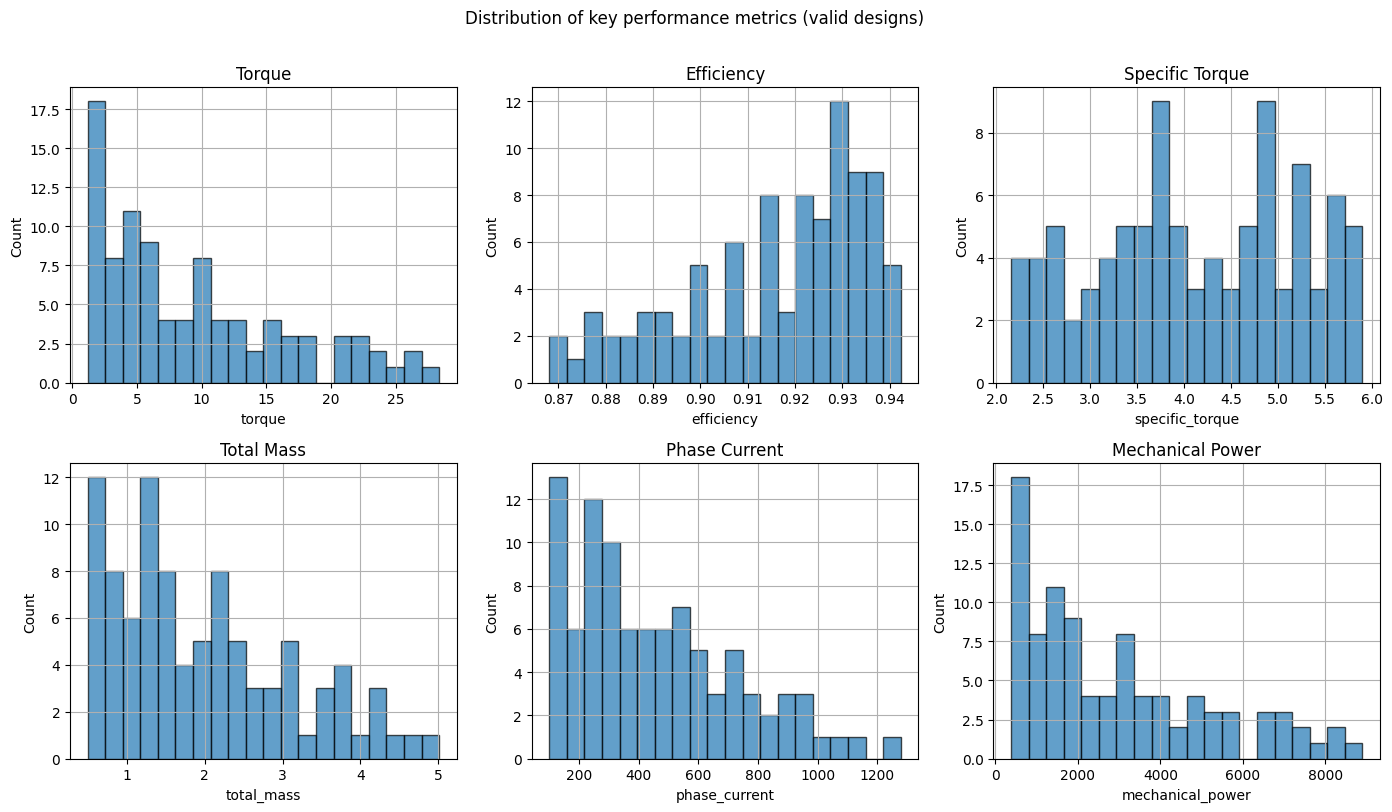

In [8]:
metrics = ['torque', 'efficiency', 'specific_torque', 'total_mass',
           'phase_current', 'mechanical_power']
available = [m for m in metrics if m in df_valid.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, available):
    df_valid[col].hist(ax=ax, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
for ax in axes.flat[len(available):]:
    ax.set_visible(False)
fig.suptitle('Distribution of key performance metrics (valid designs)', y=1.01)
fig.tight_layout()
plt.show()

## FEMM Torque Sweep

Process every valid FEM model from the dataset generated above:

For each valid model:

1. **Find optimal commutation angle** (`iq_angle_optimo`) specific to that design.
2. **Sweep 360 electrical degrees** with synchronised dq currents at the optimal angle.
3. **Compute FFT** of the torque waveform and store the first 10 harmonics.

**Outputs:**
- `dataset/torque_results.csv` -- one row per model with harmonics and mean torque
- `dataset/torque_waveforms/modelXXXX.csv` -- full waveform per model

In [9]:
import math
import femm
import numpy as np


def dq_to_abc(id_a, iq_a, theta_e_rad):
    """Inverse Park transform: dq -> abc."""
    c = math.cos(theta_e_rad)
    s = math.sin(theta_e_rad)

    i_alpha = c * id_a - s * iq_a
    i_beta  = s * id_a + c * iq_a

    ia = i_alpha
    ib = -0.5 * i_alpha + math.sqrt(3) / 2 * i_beta
    ic = -0.5 * i_alpha - math.sqrt(3) / 2 * i_beta
    return ia, ib, ic


def load_model(fem_path):
    femm.opendocument(fem_path)


def solve():
    femm.mi_analyze(1)
    femm.mi_loadsolution()


def set_sliding_band_angle(band_name, band_pos_deg):
    femm.mi_modifyboundprop(band_name, 11, band_pos_deg)


def get_torque_slidingband(band_name):
    return float(femm.mo_gapintegral(band_name, 0))


def set_currents(circuits, ia, ib, ic):
    femm.mi_modifycircprop(circuits["A"], 1, ia)
    femm.mi_modifycircprop(circuits["B"], 1, ib)
    femm.mi_modifycircprop(circuits["C"], 1, ic)

Funciones auxiliares de análisis electromagnético

In [10]:
def read_designs(csv_path: str) -> list:
    """Read designs.csv and return rows as list of dicts (only valid models)."""
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if int(row["error_code"]) != 0:
                continue
            fem_file = row.get("fem_file", "").strip()
            if not fem_file:
                continue
            rows.append(row)
    return rows


def find_iq_angle(fem_path: str, pp: int, iq: float,
                  n_steps: int = 72) -> float:
    """
    Find the rotor mechanical angle that maximises torque for id=0, iq=const.

    Sweeps one full electrical cycle (360/pp mechanical degrees) with fixed
    stator current (theta_e=0) and returns the band position of max torque.
    """
    mech_range = 360.0 / pp
    delta = mech_range / n_steps

    load_model(fem_path)

    ia, ib, ic = dq_to_abc(0.0, iq, 0.0)
    set_currents(CIRCUITS, ia, ib, ic)

    set_sliding_band_angle(BAND_NAME, 0.0)
    solve()
    T0 = get_torque_slidingband(BAND_NAME)

    best_angle = 0.0
    best_abs_T = abs(T0)
    best_T_signed = T0

    direction = 1
    angle = 0.0

    for k in range(1, n_steps):
        angle += direction * delta

        set_sliding_band_angle(BAND_NAME, angle)
        solve()
        T = get_torque_slidingband(BAND_NAME)

        abs_T = abs(T)
        if abs_T > best_abs_T:
            best_abs_T = abs_T
            best_T_signed = T
            best_angle = angle
        else:
            if k == 1:
                direction = -direction
                angle = 0.0
            else:
                break

    if best_T_signed < 0:
        best_T_signed = -best_T_signed
        best_angle += 360.0 / pp

    femm.mi_close()
    print(f"  Optimal iq angle: {best_angle:.4f} mech deg  "
          f"(torque = {best_T_signed:.4f} N·m)")
    return best_angle


def sweep_torque(fem_path: str, pp: int, iq: float,
                 iq_angle: float, n_steps: int = 72) -> dict:
    """
    Sweep one electrical cycle synchronously and return the torque waveform.

    Returns dict with keys: theta_e_deg[], band_pos_deg[], torque[].
    """
    mech_range = 360.0 / pp
    delta_mech = mech_range / n_steps

    load_model(fem_path)

    theta_e_list = []
    band_pos_list = []
    torque_list = []

    for k in range(n_steps):
        band_pos = iq_angle + k * delta_mech
        theta_e  = pp * k * delta_mech * math.pi / 180.0

        ia, ib, ic = dq_to_abc(0.0, iq, theta_e)
        set_currents(CIRCUITS, ia, ib, ic)
        set_sliding_band_angle(BAND_NAME, band_pos)

        solve()
        T = get_torque_slidingband(BAND_NAME)

        theta_e_list.append(k * 360.0 / n_steps)
        band_pos_list.append(band_pos)
        torque_list.append(T)

    femm.mi_close()

    return {
        "theta_e_deg": theta_e_list,
        "band_pos_deg": band_pos_list,
        "torque": torque_list,
    }


def torque_harmonics(torque, n_harmonics: int = 10):
    """
    Compute FFT of the torque waveform.

    Returns (amplitudes[0..n_harmonics-1], phases_deg[0..n_harmonics-1]).
    Amplitude[0] is the DC component (mean torque).
    """
    arr = np.array(torque)
    N = len(arr)
    spectrum = np.fft.rfft(arr)

    amplitudes = np.abs(spectrum) / N
    amplitudes[1:] = amplitudes[1:] * 2

    phases = np.angle(spectrum, deg=True)

    n = min(n_harmonics, len(amplitudes))
    amp_out   = list(amplitudes[:n])  + [0.0] * (n_harmonics - n)
    phase_out = list(phases[:n])      + [0.0] * (n_harmonics - n)

    return amp_out, phase_out


def save_waveform(out_path: str, waveform: dict) -> None:
    """Save a single torque waveform to CSV."""
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["step", "theta_e_deg", "band_pos_deg", "torque"])
        for k in range(len(waveform["torque"])):
            w.writerow([
                k,
                f"{waveform['theta_e_deg'][k]:.4f}",
                f"{waveform['band_pos_deg'][k]:.4f}",
                f"{waveform['torque'][k]:.6f}",
            ])

In [11]:
import os

OUTPUT_DIR   = os.path.join(os.getcwd(), "dataset")
DESIGNS_DIR  = os.path.join(OUTPUT_DIR, "designs")
WAVEFORM_DIR = os.path.join(OUTPUT_DIR, "torque_waveforms")
RESULTS_PATH = os.path.join(OUTPUT_DIR, "torque_results.csv")

CIRCUITS = {"A": "A", "B": "B", "C": "C"}
BAND_NAME = "SlidingBand"

N_HARMONICS          = 10   # DC + harmonics 1..9
SWEEP_SAMPLES        = 72   # points per electrical cycle
ANGLE_SEARCH_SAMPLES = 72   # points for iq-angle search

print(f"Designs dir  : {DESIGNS_DIR}")
print(f"Waveform dir : {WAVEFORM_DIR}")
print(f"Results CSV  : {RESULTS_PATH}")

Designs dir  : c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\designs
Waveform dir : c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\torque_waveforms
Results CSV  : c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\torque_results.csv


In [12]:
import time
import csv

t0 = time.time()

csv_path = os.path.join(OUTPUT_DIR, 'designs.csv')
designs = read_designs(csv_path)
print(f"Found {len(designs)} valid models in {csv_path}")
if not designs:
    raise RuntimeError("No valid models to process.")

pp = int(designs[0]["pp"])

# --- Load previously computed results ---
existing_results = {}
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, newline="") as f:
        for r in csv.DictReader(f):
            existing_results[int(r["sample_id"])] = r
    print(f"Loaded {len(existing_results)} previously computed results")

def _is_evaluated(row):
    sid = int(row["sample_id"])
    if sid not in existing_results:
        return False
    fem_file = row["fem_file"]
    ans_path = os.path.join(DESIGNS_DIR, fem_file.replace(".fem", ".ans"))
    wf_path  = os.path.join(WAVEFORM_DIR, fem_file.replace(".fem", ".csv"))
    return os.path.isfile(ans_path) and os.path.isfile(wf_path)

pending = [(idx, row) for idx, row in enumerate(designs)
           if not _is_evaluated(row)]
already_done = len(designs) - len(pending)
print(f"Already evaluated : {already_done}/{len(designs)}")
print(f"Pending           : {len(pending)}")

if not pending:
    print("\nAll designs already evaluated — nothing to do.")
else:
    results_rows = [existing_results[int(r["sample_id"])]
                    for r in designs
                    if int(r["sample_id"]) in existing_results]

    def _save_results(rows):
        if not rows:
            return
        fnames = list(rows[0].keys())
        with open(RESULTS_PATH, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fnames)
            w.writeheader()
            w.writerows(rows)

    femm.openfemm(1)
    os.makedirs(WAVEFORM_DIR, exist_ok=True)

    processed = 0
    interrupted = False

    try:
        for pend_i, (idx, row) in enumerate(pending):
            sample_id = int(row["sample_id"])
            fem_file  = row["fem_file"]
            fem_path  = os.path.join(DESIGNS_DIR, fem_file)
            iq_val    = float(row["phase_current"])

            if not os.path.isfile(fem_path):
                print(f"  [{pend_i+1}/{len(pending)}] {fem_file} -- NOT FOUND, skip")
                continue

            print(f"  [{pend_i+1}/{len(pending)}] "
                  f"(global {idx+1}/{len(designs)}) "
                  f"{fem_file}  (iq = {iq_val:.2f} A) ...",
                  end="", flush=True)

            try:
                iq_angle_optimo = find_iq_angle(
                    fem_path, pp, iq_val, n_steps=ANGLE_SEARCH_SAMPLES)
                waveform = sweep_torque(
                    fem_path, pp, iq_val, iq_angle_optimo,
                    n_steps=SWEEP_SAMPLES)
            except Exception as e:
                print(f" ERROR: {e}")
                continue

            amps, phases = torque_harmonics(waveform["torque"], N_HARMONICS)

            wf_name = fem_file.replace(".fem", ".csv")
            save_waveform(os.path.join(WAVEFORM_DIR, wf_name), waveform)

            res = {
                "sample_id": sample_id,
                "iq_angle_optimo": f"{iq_angle_optimo:.4f}",
                "iq": f"{iq_val:.4f}",
                "torque_mean": f"{amps[0]:.6f}",
            }
            for h in range(N_HARMONICS):
                res[f"h{h}_amp"]   = f"{amps[h]:.6f}"
                res[f"h{h}_phase"] = f"{phases[h]:.4f}"

            results_rows.append(res)
            processed += 1
            print(f"  T_mean={amps[0]:.4f} N·m")

            _save_results(results_rows)

    except KeyboardInterrupt:
        interrupted = True
        print(f"\n\n*** Interrupted after {processed} new models ***")
        _save_results(results_rows)
        print(f"Progress saved to {RESULTS_PATH}")
    finally:
        try:
            femm.closefemm()
        except Exception:
            pass

    elapsed = time.time() - t0
    total = len(results_rows)
    print(f"\nProcessed {processed} new models in {elapsed:.1f} s")
    print(f"Total results: {total}/{len(designs)}")
    if results_rows:
        print(f"Results saved to {RESULTS_PATH}")
        print(f"Waveforms in {WAVEFORM_DIR}/")
    if interrupted:
        print("\nRe-run this cell to continue from where it left off.")

Found 94 valid models in c:\Doctorado-UNLP\Cursos\Aprendizaje de maquinas\Trabajo_final\dataset\designs.csv
Already evaluated : 0/94
Pending           : 94
  [1/94] (global 1/94) model0001.fem  (iq = 590.65 A) ...  Optimal iq angle: 3.3333 mech deg  (torque = 11.8289 N·m)
  T_mean=11.5655 N·m
  [2/94] (global 2/94) model0002.fem  (iq = 172.19 A) ...  Optimal iq angle: -0.8333 mech deg  (torque = 2.2161 N·m)
  T_mean=1.9442 N·m
  [3/94] (global 3/94) model0003.fem  (iq = 780.86 A) ...  Optimal iq angle: 2.9167 mech deg  (torque = 17.9301 N·m)
  T_mean=18.1316 N·m
  [4/94] (global 4/94) model0004.fem  (iq = 590.38 A) ...  Optimal iq angle: 2.9167 mech deg  (torque = 12.2521 N·m)
  T_mean=12.1264 N·m
  [5/94] (global 5/94) model0005.fem  (iq = 390.76 A) ...  Optimal iq angle: 2.9167 mech deg  (torque = 8.0113 N·m)
  T_mean=7.9211 N·m
  [6/94] (global 6/94) model0006.fem  (iq = 284.32 A) ...  Optimal iq angle: -0.8333 mech deg  (torque = 2.4518 N·m)
  T_mean=2.2535 N·m
  [7/94] (global 7/9

## Torque Sweep Visualization

In [13]:
import pandas as pd

df_torque = pd.read_csv(RESULTS_PATH)
print(f"Torque results: {len(df_torque)} models\n")
df_torque.head()


Torque results: 93 models



,sample_id,iq_angle_optimo,iq,torque_mean,h0_amp,h0_phase,h1_amp,h1_phase,h2_amp,h2_phase,...,h5_amp,h5_phase,h6_amp,h6_phase,h7_amp,h7_phase,h8_amp,h8_phase,h9_amp,h9_phase
0,1,3.3333,590.6499,11.565469,11.565469,0.0,0.001976,-160.6475,0.207023,-104.5807,...,0.000663,-166.0384,0.404931,-23.2083,0.000111,5.4943,0.009113,51.7020,0.000956,-85.9892
1,2,-0.8333,172.1897,1.944167,1.944167,0.0,0.000136,107.9024,0.007870,-158.4436,...,0.000238,128.4397,0.358441,44.7398,0.000185,-130.2995,0.000308,155.3737,0.000352,137.1508
2,3,2.9167,780.8554,18.131568,18.131568,0.0,0.004334,-165.3184,0.373998,-108.8137,...,0.000931,161.4777,0.131363,101.8214,0.000738,68.8481,0.014540,178.8136,0.001226,134.3487
3,4,2.9167,590.3804,12.126420,12.126420,0.0,0.002291,-149.6679,0.135551,-104.9969,...,0.001173,-154.9904,0.232193,-45.1080,0.001180,-80.0356,0.013704,32.7882,0.000478,99.3938
4,5,2.9167,390.7572,7.921057,7.921057,0.0,0.000327,-136.6699,0.020960,-95.0465,...,0.000446,121.8119,0.295237,-70.7263,0.000950,81.6036,0.005891,105.7696,0.000672,-135.5493


### Visualización de resultados del dataset

La siguiente celda genera un panel de 6 gráficos que permiten inspeccionar la calidad y distribución del dataset generado:

1. **Torque medio por modelo** — Diagrama de barras del torque medio (componente DC de la forma de onda) para cada diseño simulado. Permite verificar la dispersión de la variable objetivo principal.
2. **Formas de onda de torque** — Superposición de las primeras formas de onda completas (torque vs. ángulo eléctrico) para inspeccionar visualmente el contenido armónico y el nivel de ripple.
3. **Espectro armónico** — Amplitud de cada armónico de Fourier para un diseño representativo. Muestra cómo se distribuye la energía de la señal de torque entre el valor medio (h0) y los armónicos superiores (h2, h6, etc.).
4. **Torque analítico vs. FEMM** — Diagrama de dispersión que compara el torque calculado por el modelo analítico paramétrico contra el torque medio obtenido por FEA. Los puntos cercanos a la recta `y = x` indican buena concordancia; las desviaciones revelan dónde el modelo analítico necesita corrección (justificación del enfoque PANN).
5. **Torque específico vs. masa** — Relación entre el torque específico (torque medio FEA / masa total) y la masa del motor, útil para identificar diseños con alta densidad de torque.
6. **Torque específico vs. torque** — Relación entre el torque específico y el torque medio absoluto, que permite visualizar el compromiso entre rendimiento absoluto y densidad de potencia en el espacio de diseño muestreado.

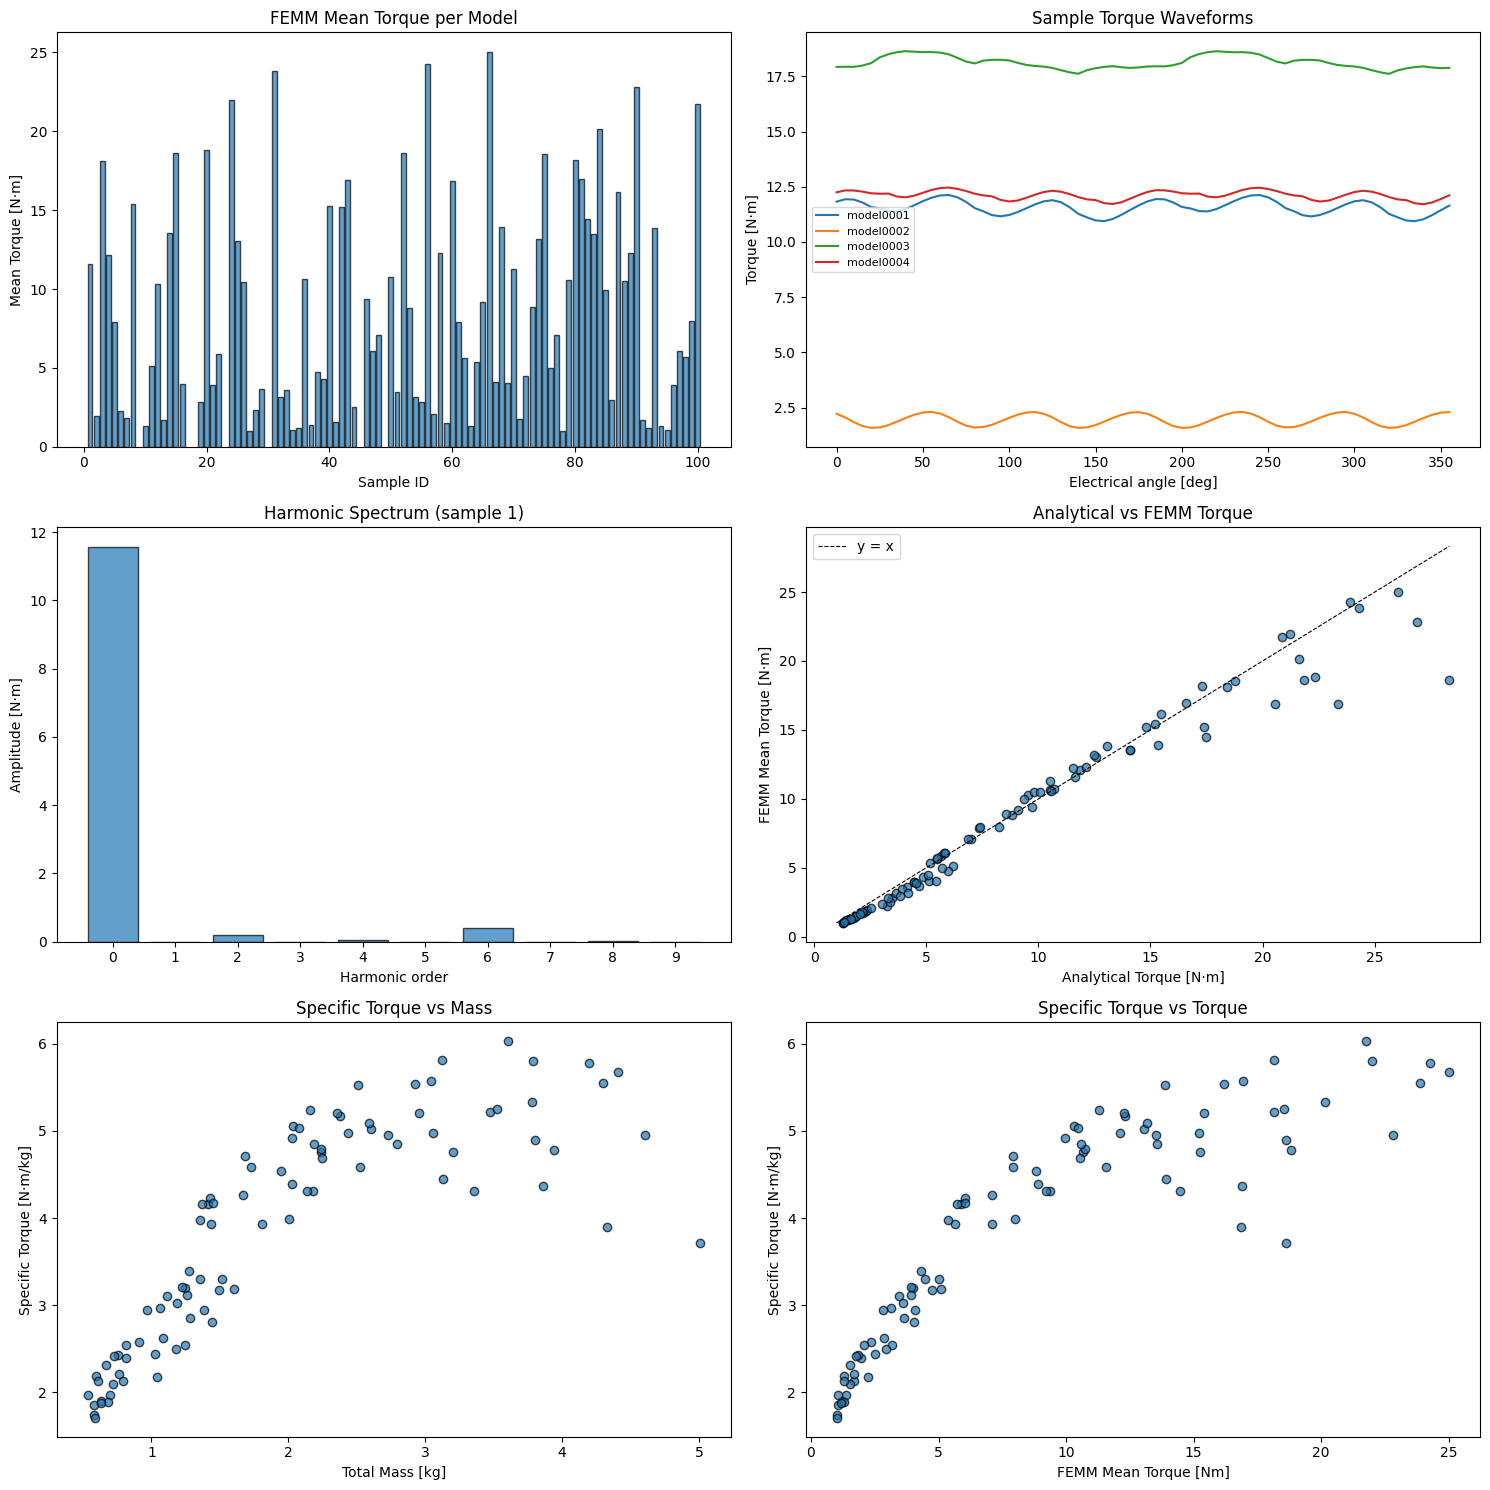

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# --- 1) Mean torque per model (bar chart) ---
ax = axes[0, 0]
ax.bar(df_torque["sample_id"], df_torque["torque_mean"], edgecolor="black", alpha=0.7)
ax.set_xlabel("Sample ID")
ax.set_ylabel("Mean Torque [N·m]")
ax.set_title("FEMM Mean Torque per Model")

# --- 2) Overlay of sample torque waveforms ---
ax = axes[0, 1]
waveform_files = sorted([
    f for f in os.listdir(WAVEFORM_DIR) if f.endswith(".csv")
])
n_show = min(4, len(waveform_files))
for wf_file in waveform_files[:n_show]:
    wf = pd.read_csv(os.path.join(WAVEFORM_DIR, wf_file))
    ax.plot(wf["theta_e_deg"], wf["torque"], label=wf_file.replace(".csv", ""))
ax.set_xlabel("Electrical angle [deg]")
ax.set_ylabel("Torque [N·m]")
ax.set_title("Sample Torque Waveforms")
ax.legend(fontsize=8)

# --- 3) Harmonic spectrum for one representative model ---
ax = axes[1, 0]
rep = df_torque.iloc[0]
harm_amps = [rep[f"h{h}_amp"] for h in range(N_HARMONICS)]
ax.bar(range(N_HARMONICS), harm_amps, edgecolor="black", alpha=0.7)
ax.set_xlabel("Harmonic order")
ax.set_ylabel("Amplitude [N·m]")
ax.set_title(f"Harmonic Spectrum (sample {int(rep['sample_id'])})")
ax.set_xticks(range(N_HARMONICS))

# --- 4) Analytical torque vs FEMM mean torque ---
ax = axes[1, 1]
df_designs = pd.read_csv(csv_path)
df_cmp = df_designs.merge(df_torque[["sample_id", "torque_mean"]],
                          on="sample_id", suffixes=("_analytical", "_femm"))
if len(df_cmp) > 0:
    ax.scatter(df_cmp["torque"], df_cmp["torque_mean"], edgecolors="black", alpha=0.7)
    t_range = [
        min(df_cmp["torque"].min(), df_cmp["torque_mean"].min()),
        max(df_cmp["torque"].max(), df_cmp["torque_mean"].max()),
    ]
    ax.plot(t_range, t_range, "k--", linewidth=0.8, label="y = x")
    ax.set_xlabel("Analytical Torque [N·m]")
    ax.set_ylabel("FEMM Mean Torque [N·m]")
    ax.set_title("Analytical vs FEMM Torque")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No matching samples", transform=ax.transAxes,
            ha="center", va="center")

# --- 5) Specific torque (FEMM mean torque / mass) vs mass ---
ax = axes[2, 0]
if len(df_cmp) > 0:
    specific_torque = df_cmp["torque_mean"] / df_cmp["total_mass"]
    ax.scatter(df_cmp["total_mass"], specific_torque, edgecolors="black", alpha=0.7)
    ax.set_xlabel("Total Mass [kg]")
    ax.set_ylabel("Specific Torque [N·m/kg]")
    ax.set_title("Specific Torque vs Mass")
else:
    ax.text(0.5, 0.5, "No matching samples", transform=ax.transAxes,
            ha="center", va="center")

# --- 6) Specific torque (FEMM mean torque / mass) vs FEMM mean torque ---
ax = axes[2, 1]
if len(df_cmp) > 0:
    specific_torque = df_cmp["torque_mean"] / df_cmp["total_mass"]
    ax.scatter(df_cmp["torque_mean"], specific_torque, edgecolors="black", alpha=0.7)
    ax.set_xlabel("FEMM Mean Torque [Nm]")
    ax.set_ylabel("Specific Torque [N·m/kg]")
    ax.set_title("Specific Torque vs Torque")
else:
    ax.text(0.5, 0.5, "No matching samples", transform=ax.transAxes,
            ha="center", va="center")

fig.tight_layout()
plt.show()

### Exactitud del modelo analítico

El gráfico de torque analítico vs. torque FEMM muestra una muy buena concordancia entre ambos valores: los puntos se agrupan estrechamente sobre la recta identidad `y = x`, lo que indica que el modelo paramétrico analítico captura con alta fidelidad el torque medio del motor. Esto es esperable, ya que el modelo analítico [1] fue diseñado para predecir con precisión las magnitudes de primer orden (torque medio, densidad de flujo fundamental), y las mayores discrepancias se concentran en fenómenos de orden superior como el ripple y el cogging torque, que dependen de efectos geométricos locales (aperturas de ranura, saturación) no contemplados por el modelo simplificado. Esta observación justifica el enfoque PANN: dado que el modelo analítico ya provee una buena estimación base, la red neuronal solo necesita aprender las *correcciones residuales* introducidas por el FEA, lo que reduce la complejidad del problema de aprendizaje y mejora la eficiencia en el uso de los datos de entrenamiento.

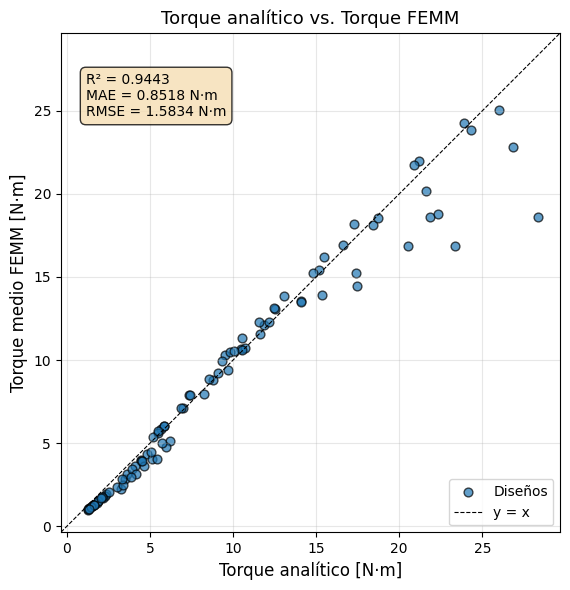

In [15]:
import matplotlib.pyplot as plt
import numpy as np

df_designs = pd.read_csv(csv_path)
df_cmp = df_designs.merge(
    df_torque[["sample_id", "torque_mean"]],
    on="sample_id",
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(df_cmp["torque"], df_cmp["torque_mean"],
           edgecolors="black", alpha=0.7, s=40, label="Diseños")

t_min = min(df_cmp["torque"].min(), df_cmp["torque_mean"].min())
t_max = max(df_cmp["torque"].max(), df_cmp["torque_mean"].max())
margin = (t_max - t_min) * 0.05
t_range = [t_min - margin, t_max + margin]
ax.plot(t_range, t_range, "k--", linewidth=0.8, label="y = x")

errors = df_cmp["torque_mean"] - df_cmp["torque"]
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors**2))
r2 = 1 - np.sum(errors**2) / np.sum((df_cmp["torque_mean"] - df_cmp["torque_mean"].mean())**2)

ax.text(0.05, 0.92, f"R² = {r2:.4f}\nMAE = {mae:.4f} N·m\nRMSE = {rmse:.4f} N·m",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.8))

ax.set_xlabel("Torque analítico [N·m]", fontsize=12)
ax.set_ylabel("Torque medio FEMM [N·m]", fontsize=12)
ax.set_title("Torque analítico vs. Torque FEMM", fontsize=13)
ax.set_xlim(t_range)
ax.set_ylim(t_range)
ax.set_aspect("equal")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Harmonic Amplitude Relevance Analysis

Identify which harmonic amplitude columns (`h0_amp` … `h9_amp`) carry meaningful information
and which are negligible (near-zero or orders of magnitude smaller than the dominant harmonics).

=== Descriptive statistics for harmonic amplitudes ===



,mean,std,min,max,cv,max/h0_mean
h0_amp,8.848994,6.746126,1.005015,25.023059,0.762361,1.000000
h1_amp,0.002418,0.003937,0.000018,0.018900,1.628126,0.000273
h2_amp,0.127612,0.180717,0.001694,0.743887,1.416144,0.014421
h3_amp,0.002565,0.003426,0.000018,0.015128,1.335992,0.000290
h4_amp,0.027480,0.026251,0.001080,0.116900,0.955288,0.003105
h5_amp,0.000841,0.000845,0.000049,0.003457,1.004509,0.000095
h6_amp,0.461632,0.276151,0.028261,1.818140,0.598206,0.052168
h7_amp,0.000588,0.000461,0.000032,0.002023,0.783534,0.000066
h8_amp,0.012781,0.015469,0.000185,0.077830,1.210248,0.001444
h9_amp,0.000800,0.000541,0.000028,0.002495,0.676164,0.000090



Mean of h0_amp (DC / mean torque): 8.8490 N·m
Relevance threshold: 1% of h0 mean = 0.088490 N·m

RELEVANT harmonics  (>= 1%): ['h0_amp', 'h2_amp', 'h6_amp']
NEGLIGIBLE harmonics (< 1%): ['h1_amp', 'h3_amp', 'h4_amp', 'h5_amp', 'h7_amp', 'h8_amp', 'h9_amp']


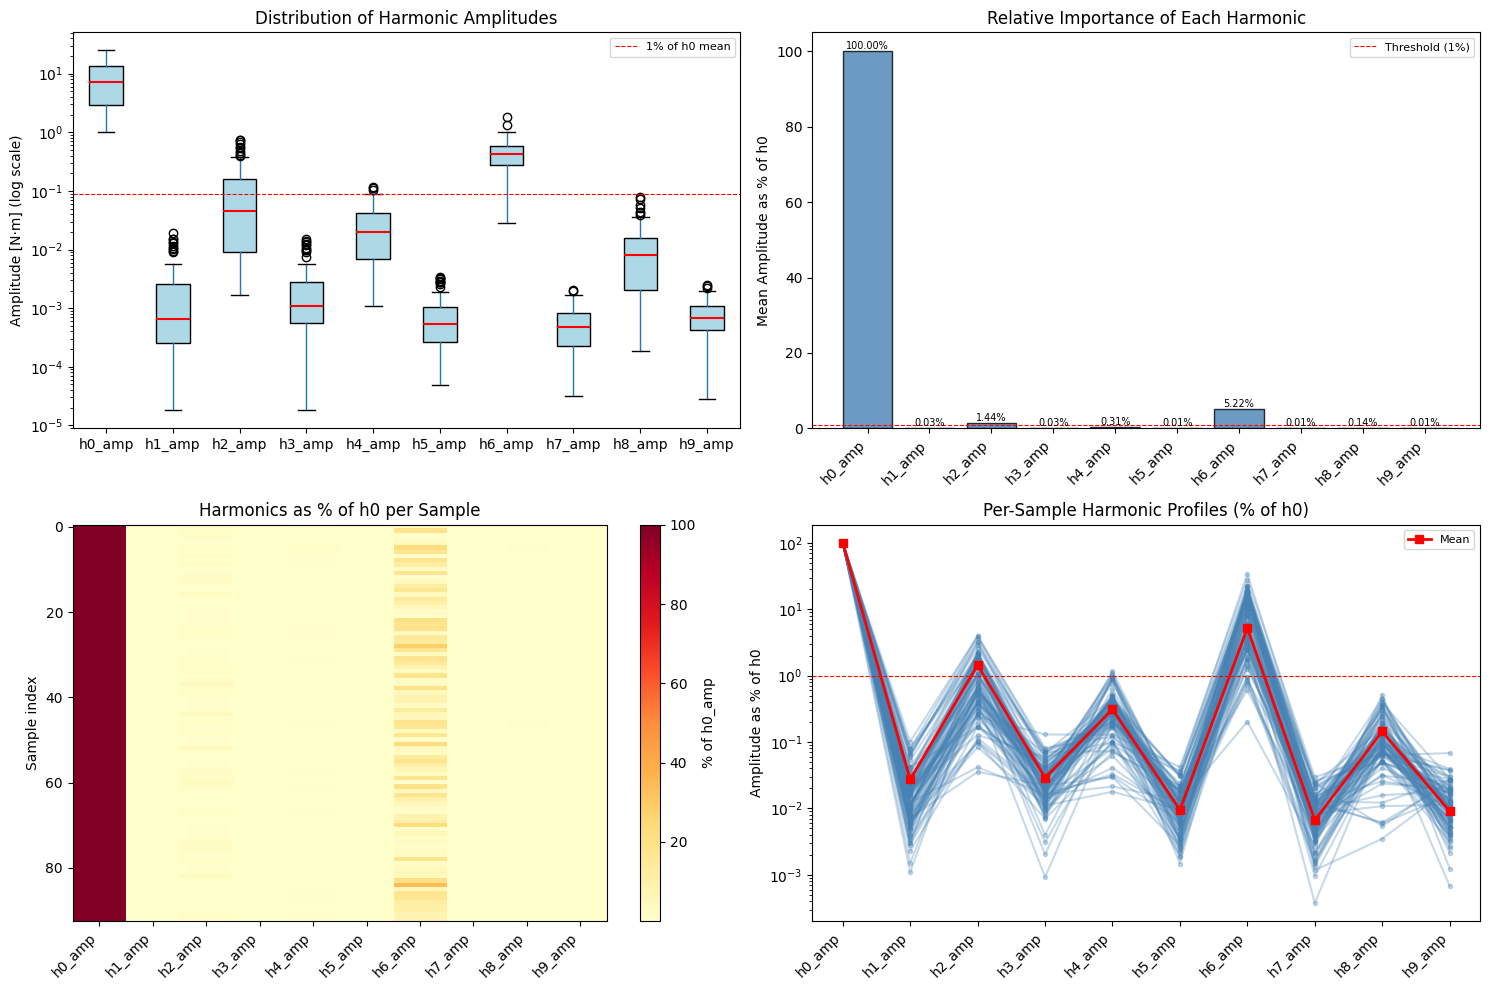


RECOMMENDATION FOR FEATURE SELECTION

Columns SAFE TO DROP (mean < 1% of h0):
  - h1_amp      mean = 0.002418 N·m  (0.0273% of h0)
  - h3_amp      mean = 0.002565 N·m  (0.0290% of h0)
  - h4_amp      mean = 0.027480 N·m  (0.3105% of h0)
  - h5_amp      mean = 0.000841 N·m  (0.0095% of h0)
  - h7_amp      mean = 0.000588 N·m  (0.0066% of h0)
  - h8_amp      mean = 0.012781 N·m  (0.1444% of h0)
  - h9_amp      mean = 0.000800 N·m  (0.0090% of h0)

Columns to KEEP:
  - h0_amp      mean = 8.848994 N·m  (100.00% of h0)
  - h2_amp      mean = 0.127612 N·m  (1.44% of h0)
  - h6_amp      mean = 0.461632 N·m  (5.22% of h0)


In [16]:
amp_cols = [f"h{h}_amp" for h in range(N_HARMONICS)]
df_amps = df_torque[amp_cols]

# --- Descriptive statistics ---
stats = df_amps.describe().T
stats["cv"] = stats["std"] / stats["mean"].replace(0, np.nan)
stats["max/h0_mean"] = stats["mean"] / df_amps["h0_amp"].mean()
print("=== Descriptive statistics for harmonic amplitudes ===\n")
display(stats[["mean", "std", "min", "max", "cv", "max/h0_mean"]].round(6))

# --- Threshold analysis ---
RELEVANCE_THRESHOLD = 0.01  # 1% of h0 mean
h0_mean = df_amps["h0_amp"].mean()
mean_amps = df_amps.mean()
negligible = mean_amps[mean_amps / h0_mean < RELEVANCE_THRESHOLD]
relevant = mean_amps[mean_amps / h0_mean >= RELEVANCE_THRESHOLD]

print(f"\nMean of h0_amp (DC / mean torque): {h0_mean:.4f} N·m")
print(f"Relevance threshold: {RELEVANCE_THRESHOLD*100:.0f}% of h0 mean = {h0_mean * RELEVANCE_THRESHOLD:.6f} N·m\n")
print(f"RELEVANT harmonics  (>= {RELEVANCE_THRESHOLD*100:.0f}%): {list(relevant.index)}")
print(f"NEGLIGIBLE harmonics (< {RELEVANCE_THRESHOLD*100:.0f}%): {list(negligible.index)}")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) Boxplot of raw amplitudes (log scale to see small ones)
ax = axes[0, 0]
df_amps.boxplot(ax=ax, grid=False, patch_artist=True,
                boxprops=dict(facecolor="lightblue", edgecolor="black"),
                medianprops=dict(color="red", linewidth=1.5))
ax.set_yscale("log")
ax.set_ylabel("Amplitude [N·m] (log scale)")
ax.set_title("Distribution of Harmonic Amplitudes")
ax.axhline(h0_mean * RELEVANCE_THRESHOLD, color="red", linestyle="--", linewidth=0.8,
           label=f"{RELEVANCE_THRESHOLD*100:.0f}% of h0 mean")
ax.legend(fontsize=8)

# 2) Mean amplitude as % of h0 (bar chart)
ax = axes[0, 1]
pct_of_h0 = (mean_amps / h0_mean * 100)
colors = ["steelblue" if v >= RELEVANCE_THRESHOLD * 100 else "salmon" for v in pct_of_h0]
bars = ax.bar(range(N_HARMONICS), pct_of_h0, color=colors, edgecolor="black", alpha=0.8)
ax.set_xticks(range(N_HARMONICS))
ax.set_xticklabels(amp_cols, rotation=45, ha="right")
ax.set_ylabel("Mean Amplitude as % of h0")
ax.set_title("Relative Importance of Each Harmonic")
ax.axhline(RELEVANCE_THRESHOLD * 100, color="red", linestyle="--", linewidth=0.8,
           label=f"Threshold ({RELEVANCE_THRESHOLD*100:.0f}%)")
ax.legend(fontsize=8)
for bar, val in zip(bars, pct_of_h0):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.2f}%", ha="center", va="bottom", fontsize=7)

# 3) Heatmap: each row is a design, columns are harmonics (normalized by h0 of that row)
ax = axes[1, 0]
normalized = df_amps.div(df_amps["h0_amp"], axis=0) * 100
im = ax.imshow(normalized.values, aspect="auto", cmap="YlOrRd",
               interpolation="nearest")
ax.set_xticks(range(N_HARMONICS))
ax.set_xticklabels(amp_cols, rotation=45, ha="right")
ax.set_ylabel("Sample index")
ax.set_title("Harmonics as % of h0 per Sample")
plt.colorbar(im, ax=ax, label="% of h0_amp")

# 4) Stacked view: all samples overlaid as thin lines
ax = axes[1, 1]
for i in range(len(df_amps)):
    row_pct = df_amps.iloc[i].values / df_amps.iloc[i]["h0_amp"] * 100
    ax.plot(range(N_HARMONICS), row_pct, "o-", alpha=0.3, markersize=3, color="steelblue")
ax.plot(range(N_HARMONICS), pct_of_h0.values, "s-", color="red", linewidth=2,
        markersize=6, label="Mean", zorder=10)
ax.set_xticks(range(N_HARMONICS))
ax.set_xticklabels(amp_cols, rotation=45, ha="right")
ax.set_ylabel("Amplitude as % of h0")
ax.set_title("Per-Sample Harmonic Profiles (% of h0)")
ax.set_yscale("log")
ax.axhline(RELEVANCE_THRESHOLD * 100, color="red", linestyle="--", linewidth=0.8)
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

# --- Summary recommendation ---
print("\n" + "=" * 60)
print("RECOMMENDATION FOR FEATURE SELECTION")
print("=" * 60)
print(f"\nColumns SAFE TO DROP (mean < {RELEVANCE_THRESHOLD*100:.0f}% of h0):")
for col in negligible.index:
    print(f"  - {col:10s}  mean = {negligible[col]:.6f} N·m  "
          f"({negligible[col]/h0_mean*100:.4f}% of h0)")
print(f"\nColumns to KEEP:")
for col in relevant.index:
    print(f"  - {col:10s}  mean = {relevant[col]:.6f} N·m  "
          f"({relevant[col]/h0_mean*100:.2f}% of h0)")